In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")

print("Path to dataset files:", path)

Скачиваем Deepfake Dataset c Kaggle.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc 
from sklearn.metrics import precision_recall_curve

Этот блок импортирует все необходимые библиотеки для построения, обучения и оценки модели. Здесь включены инструменты для:
AUC).

Обработки данных (ImageDataGenerator).
Настройки и работы с предобученными нейронными сетями (MobileNetV2).
Регуляризации и оптимизации обучения (колбэки).
Оценки результатов модели (ROC AUC, ROC PR).

In [3]:
# Отключение предупреждений
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

# Отключение логов от XLA и CUDA
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow")

tf.config.optimizer.set_jit(False)  # Отключение XLA (по умолчанию True)

Этот блок используется для упрощения и минимизации вывода в консоли во время выполнения программы. Это особенно полезно при работе с большими моделями, где консоль может быть перегружена избыточной информацией от TensorFlow, CUDA или XLA.

In [4]:
# Пути к данным (заполните в соответствии с вашим датасетом)
train_dir = '/kaggle/input/deepfake-and-real-images/Dataset/Train'
val_dir = '/kaggle/input/deepfake-and-real-images/Dataset/Validation'
test_dir = '/kaggle/input/deepfake-and-real-images/Dataset/Test'

# Проверяем содержимое папок
print("Train Path Contents:", os.listdir(train_dir))
print("Validation Path Contents:", os.listdir(val_dir))
print("Test Path Contents:", os.listdir(test_dir))

Train Path Contents: ['Fake', 'Real']
Validation Path Contents: ['Fake', 'Real']
Test Path Contents: ['Fake', 'Real']


Этот блок кода помогает убедиться, что данные находятся по указанным путям и организованы правильно.
В случае ошибки (FileNotFoundError) мы сможем быстро обнаружить неправильные пути или отсутствие файлов.

In [5]:
# Генераторы данных
datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

validation_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Построение модели на основе MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Заморозка всех слоев базовой модели, кроме последних 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Компиляция модели
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Указываем путь для сохранения модели
checkpoint_path = '/kaggle/working/best_model.keras'                                                           # Определение колбэков
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.


Этот блок кода:
Подготавливает данныес препроцессингом под формат мобайлнета [-1, 1]).
Создаёт и настраивает модель на основе предобученной MobileNetV2.
Определяет колбэки для управления процессом обучения и предотвращения переобучения.

In [6]:
train_accuracies = []
val_accuracies = []
test_accuracies = []

In [7]:
# Корректные шаги на эпоху
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size
# Цикл обучения
for epoch in range(20):  # Количество эпох
    print(f"Epoch {epoch + 1}/20")
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        steps_per_epoch=train_generator.samples // 32,
        validation_steps=validation_generator.samples // 32,
        epochs=1,
        verbose=1
    )

    # Извлечение метрик после каждой эпохи
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    _, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // 32, verbose=0)

    # Сохранение метрик в списки для графиков
    train_accuracies.append(train_acc)  # Сохраняем Train Accuracy
    val_accuracies.append(val_acc)  # Сохраняем Validation Accuracy
    test_accuracies.append(test_accuracy * 100)  # Сохраняем Test Accuracy (в процентах)

    # Вывод метрик в консоль
    print(f"Train Accuracy: {train_acc:.4f} - Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f} - Validation Loss: {val_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%\n")

# Вывод итоговых метрик после всех эпох
final_train_accuracy = train_accuracies[-1] * 100  # Последнее значение Train Accuracy
final_val_accuracy = val_accuracies[-1] * 100      # Последнее значение Validation Accuracy
final_test_accuracy = test_accuracies[-1]         # Последнее значение Test Accuracy (уже в процентах)

print(f"Final Train Accuracy: {final_train_accuracy:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy:.2f}%")
print(f"Final Test Accuracy: {final_test_accuracy:.2f}%")


Epoch 1/20


I0000 00:00:1734424596.355797     241 service.cc:145] XLA service 0x79f268006070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734424596.355844     241 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1734424596.355848     241 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   1/4375 ━━━━━━━━━━━━━━━━━━━━ 18:40:16 15s/step - accuracy: 0.5625 - loss: 0.7588

I0000 00:00:1734424603.462777     241 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2892/4375 ━━━━━━━━━━━━━━━━━━━━ 3:56 159ms/step - accuracy: 0.8263 - loss: 0.3793

I0000 00:00:1734425063.804222     238 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_5', 32 bytes spill stores, 32 bytes spill loads



4375/4375 ━━━━━━━━━━━━━━━━━━━━ 1035s 233ms/step - accuracy: 0.8416 - loss: 0.3507 - val_accuracy: 0.8613 - val_loss: 0.3199
Train Accuracy: 0.8766 - Train Loss: 0.2844
Validation Accuracy: 0.8613 - Validation Loss: 0.3199
Test Accuracy: 76.32%

Epoch 2/20
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 370s 85ms/step - accuracy: 0.9211 - loss: 0.1922 - val_accuracy: 0.8992 - val_loss: 0.2533
Train Accuracy: 0.9224 - Train Loss: 0.1892
Validation Accuracy: 0.8992 - Validation Loss: 0.2533
Test Accuracy: 75.63%

Epoch 3/20
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 265s 61ms/step - accuracy: 0.9450 - loss: 0.1349 - val_accuracy: 0.8994 - val_loss: 0.3100
Train Accuracy: 0.9437 - Train Loss: 0.1388
Validation Accuracy: 0.8994 - Validation Loss: 0.3100
Test Accuracy: 77.32%

Epoch 4/20
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 280s 64ms/step - accuracy: 0.9622 - loss: 0.0956 - val_accuracy: 0.9079 - val_loss: 0.2684
Train Accuracy: 0.9603 - Train Loss: 0.1005
Validation Accuracy: 0.9079 - Validation Loss: 0.2684
Test Accuracy: 7

В этом коде реализуется обучение модели для классификации изображений на DeepFake и реальные. Модель основана на предобученной архитектуре MobileNetV2, которая адаптируется под задачу бинарной классификации.ься.

Точность на обучающей выборке увеличилась с 87.66% (Epoch 1) до 99.22% (Epoch 20).
Потери уменьшились с 0.2844 (Epoch 1) до 0.0226 (Epoch 20).
Вывод: Модель хорошо обучилась на тренировочных данных. Почти 100% точности свидетельствуют о том, что модель способна правильно классифицировать тренировочные примеры. Точность на валидационной выборке увеличилась с 86.13%(Epoch 1) до 91.38% (Epoch  20). Модель показывает хорошие результаты на данных, которые она не видела во время обучения. Точность на тестовой выборке увеличила с 76.32% (Epoch 1) до 77.56% (Epoch 20). Модель демонстрирует умеренные результаты на тестовых данных. Рост точности с 1-й по 20-ю эпоху подтверждает, что модель способна обучаться.

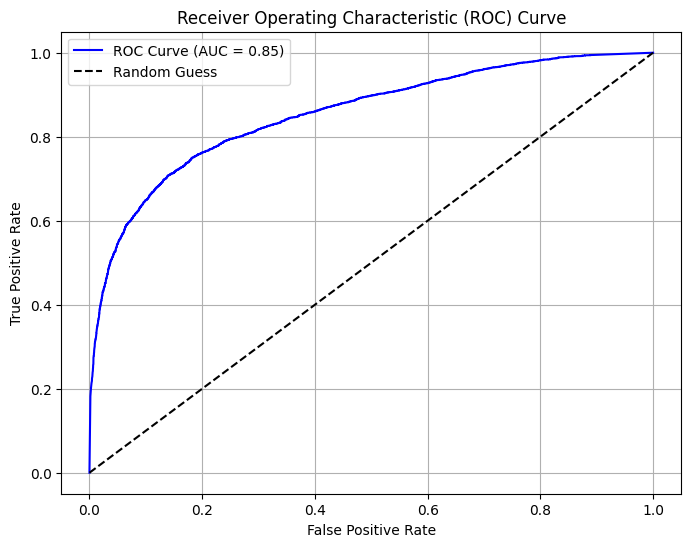

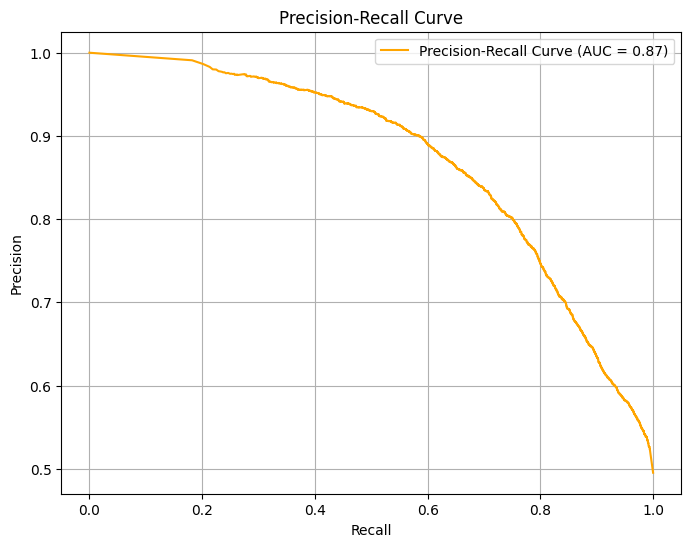

In [9]:
# Расчёт и визуализация AUC-ROC и AUC-PR
predictions = model.predict(test_generator, steps=test_generator.samples // 32, verbose=0)
y_true = test_generator.classes[:len(predictions)]

# AUC-ROC
fpr, tpr, _ = roc_curve(y_true, predictions)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# AUC-PR
precision, recall, _ = precision_recall_curve(y_true, predictions)
pr_auc = auc(recall, precision)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.2f})', color='orange')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

Площадь под кривой (AUC-ROC) составила 0.85, что говорит о хорошей способности модели разделять классы DeepFake и Real.и.

Начало кривой в точке (0, 0) с быстрым подъёмом вверх указывает, что модель хорошо распознаёт DeepFake при низких уровнях FPR.

Площадь под кривой (AUC-PR) составила 0.87, что указывает на высокую точность модели.
В начале кривой наблюдается высокая Precision (> 0.9), что демонстрирует способность модели избегать ложных срабатываний при высоких порогах классификации.

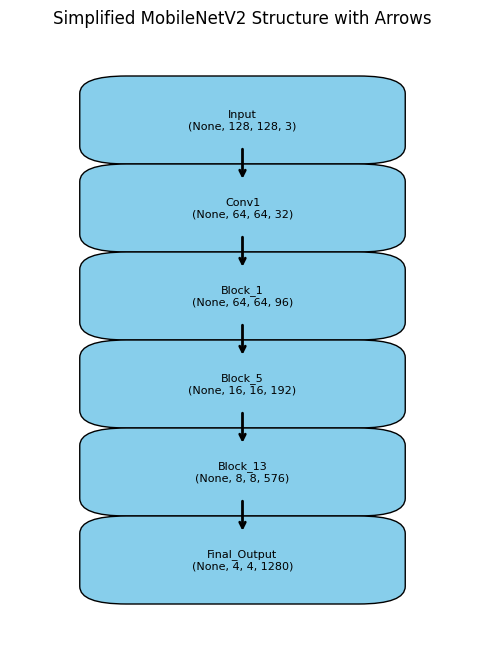

In [21]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Загружаем MobileNetV2
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Извлекаем ключевые слои
key_layers = {
    'Input': mobilenet_model.input.shape,  # Входной слой
    'Conv1': mobilenet_model.get_layer('Conv1').output.shape,  # Первый сверточный слой
    'Block_1': mobilenet_model.get_layer('block_1_expand').output.shape,  # Блок 1
    'Block_5': mobilenet_model.get_layer('block_5_expand').output.shape,  # Блок 5
    'Block_13': mobilenet_model.get_layer('block_13_expand').output.shape,  # Блок 13
    'Final_Output': mobilenet_model.get_layer('out_relu').output.shape  # Финальный блок
}

# Настройка визуализации
fig, ax = plt.subplots(figsize=(6, 8))
ax.set_xlim(0, 2)
ax.set_ylim(0, len(key_layers) + 1)

# Размещение блоков и стрелок
y_positions = list(range(len(key_layers), 0, -1))  # Позиции по оси Y
x_position = 1  # Позиция по оси X

# Добавление блоков
for i, (layer, shape) in enumerate(key_layers.items()):
    # Рисуем прямоугольник
    rect = patches.FancyBboxPatch(
        (x_position - 0.5, y_positions[i] - 0.3),  # Координаты прямоугольника
        1.0, 0.6, boxstyle="round,pad=0.2", fc="skyblue", ec="black"
    )
    ax.add_patch(rect)
    # Текст внутри прямоугольника
    ax.text(x_position, y_positions[i], f"{layer}\n{shape}",
            ha='center', va='center', fontsize=8)

    # Добавление стрелок между блоками
    if i < len(key_layers) - 1:
        ax.annotate('',
                    xy=(x_position, y_positions[i+1] + 0.3),  # Конечная точка стрелки
                    xytext=(x_position, y_positions[i] - 0.3),  # Начальная точка стрелки
                    arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Настройки графика
ax.set_axis_off()
plt.title("Simplified MobileNetV2 Structure with Arrows", fontsize=12)
plt.show()






In [ ]:
Упрощенная структура MobileNetV2 наглядно демонстрирует, как модель постепенно уменьшает размер изображения, одновременно увеличивая количество каналов. 